In [118]:
#EDA - Kenya food prices 2006-2026

In [119]:
#Libraries

import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [120]:
df = pd.read_csv('../../data/cleaned/wfp_with_rainfall.csv')

In [121]:
#show the shape of the dataset

df.shape

(27316, 18)

In [122]:
#first rows

df.head()


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,date_month,rainfall_mm
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22,2006-01-01,17.813333
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58,2006-01-01,17.813333
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47,2006-01-01,17.813333
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15,2006-01-01,17.813333
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24,2006-01-01,44.527500


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27316 entries, 0 to 27315
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          27316 non-null  str    
 1   admin1        27316 non-null  str    
 2   admin2        27316 non-null  str    
 3   market        27316 non-null  str    
 4   market_id     27316 non-null  int64  
 5   latitude      27316 non-null  float64
 6   longitude     27316 non-null  float64
 7   category      27316 non-null  str    
 8   commodity     27316 non-null  str    
 9   commodity_id  27316 non-null  int64  
 10  unit          27316 non-null  str    
 11  priceflag     27316 non-null  str    
 12  pricetype     27316 non-null  str    
 13  currency      27316 non-null  str    
 14  price         27316 non-null  float64
 15  usdprice      27316 non-null  float64
 16  date_month    27316 non-null  str    
 17  rainfall_mm   25829 non-null  float64
dtypes: float64(5), int64(2), str(11)
memo

In [124]:
#fix the date column to datetime format

df["date"]=pd.to_datetime(df["date"])

In [125]:
df["date_month"]=df["date"].dt.month
df["date_month"].dtype

dtype('int32')

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27316 entries, 0 to 27315
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          27316 non-null  datetime64[us]
 1   admin1        27316 non-null  str           
 2   admin2        27316 non-null  str           
 3   market        27316 non-null  str           
 4   market_id     27316 non-null  int64         
 5   latitude      27316 non-null  float64       
 6   longitude     27316 non-null  float64       
 7   category      27316 non-null  str           
 8   commodity     27316 non-null  str           
 9   commodity_id  27316 non-null  int64         
 10  unit          27316 non-null  str           
 11  priceflag     27316 non-null  str           
 12  pricetype     27316 non-null  str           
 13  currency      27316 non-null  str           
 14  price         27316 non-null  float64       
 15  usdprice      27316 non-null  float64       
 1

In [127]:
#check for missing values

df.isnull().sum()

date               0
admin1             0
admin2             0
market             0
market_id          0
latitude           0
longitude          0
category           0
commodity          0
commodity_id       0
unit               0
priceflag          0
pricetype          0
currency           0
price              0
usdprice           0
date_month         0
rainfall_mm     1487
dtype: int64

In [128]:
#check % of missing values in rainfall column
df["rainfall_mm"].isnull().mean() * 100

np.float64(5.443696002342949)

In [129]:
#find median rainfall to use for filling

df["rainfall_mm"].median()

np.float64(60.26)

In [130]:
#fill missing values in rainfall column with median value

df["rainfall_mm"] = df["rainfall_mm"].fillna(df["rainfall_mm"].median())


In [131]:
#check missing values again to confirm that they have been filled
df.isnull().sum()

date            0
admin1          0
admin2          0
market          0
market_id       0
latitude        0
longitude       0
category        0
commodity       0
commodity_id    0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
date_month      0
rainfall_mm     0
dtype: int64

In [132]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [133]:
#statistics for categorical columns

df.describe(include='object')

,admin1,admin2,market,category,commodity,unit,priceflag,pricetype,currency
count,27316,27316,27316,27316,27316,27316,27316,27316,27316
unique,7,27,225,8,51,13,3,2,1
top,Rift Valley,Turkana,Nairobi,cereals and tubers,Beans (dry),KG,actual,Retail,KES
freq,12126,7842,1751,11951,1806,14380,17886,18218,27316


In [134]:
df.describe()

,date,market_id,latitude,longitude,commodity_id,price,usdprice,date_month,rainfall_mm
count,27316,27316.000000,27316.000000,27316.000000,27316.000000,27316.000000,27316.000000,27316.000000,27316.000000
mean,2021-05-26 01:48:35.741689,4076.817653,0.776889,36.992876,301.791953,1317.337703,12.017051,6.527090,80.836994
min,2006-01-15 00:00:00,184.000000,-4.660000,34.360000,50.000000,5.000000,0.039000,1.000000,0.090000
25%,2021-02-15 00:00:00,1855.000000,-1.270000,34.850000,67.000000,70.000000,0.610000,3.000000,24.840000
50%,2022-10-15 00:00:00,3254.000000,0.380000,36.780000,148.000000,130.000000,1.030000,6.000000,60.260000
75%,2024-07-15 00:00:00,5670.000000,3.540000,39.020000,451.000000,1027.000000,9.445000,9.000000,111.287143
max,2026-08-15 00:00:00,10509.000000,4.620000,41.860000,937.000000,19800.000000,184.820000,12.000000,483.984000
std,NaN,3114.788378,2.295157,2.043146,297.133997,2593.837126,23.019250,3.489914,73.236852


In [135]:
#convert units to kg and calculate price per kg
import re

def to_kg(unit):
    u = str(unit).upper()
    m = re.search(r"(\d+\.?\d*)", u)
    if not m:
        return 1.0
    num = float(m.group(1))
    if "G" in u and "K" not in u:
        return num/1000
    return num

df["kg"] = df["unit"].apply(to_kg)
df["price_per_kg"] = df["price"] / df["kg"]
df["price_per_kg"].describe()

count    27316.000000
mean       111.068421
std        115.781084
min          0.040000
25%         48.340000
50%         80.000000
75%        130.000000
max        900.000000
Name: price_per_kg, dtype: float64

In [136]:
# Price per KG for every commodity
df.groupby("commodity")["price_per_kg"].mean().sort_values(ascending=False).head(10)

commodity
Meat (goat)                   624.083301
Meat (camel)                  545.758552
Meat (beef)                   542.483551
Oil (vegetable, fortified)    291.731744
Oil (vegetable)               239.742700
Pigeon peas (dry)             203.387387
Cooking fat                   188.720315
Cowpeas (dry)                 160.893836
Sugar                         156.855444
Fish (omena, dry)             151.708333
Name: price_per_kg, dtype: float64

In [137]:
# Cheapest - where maize & tomatoes are
df.groupby("commodity")["price_per_kg"].mean().sort_values().head(10)

commodity
Milk (UHT)                  0.143589
Bananas                    13.960204
Cabbage                    28.306850
Cowpea leaves              31.262500
Maize (white)              39.086307
Maize                      41.427352
Potatoes (Irish, red)      47.021840
Sorghum                    49.237533
Potatoes (Irish, white)    50.006343
Sorghum (red)              52.705793
Name: price_per_kg, dtype: float64

In [138]:
df_clean = df[(df["price_per_kg"] >= 10) & (df["price_per_kg"] <= 500)].copy()
df_clean["price_per_kg"].describe()

count    25666.000000
mean       101.308017
std         78.950098
min         10.000000
25%         50.000000
50%         80.000000
75%        125.727500
max        500.000000
Name: price_per_kg, dtype: float64

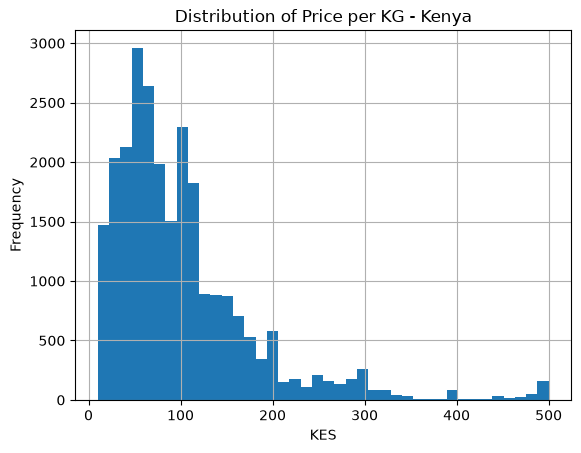

In [139]:
#distribution of price per kg
#price ditribution is righr skewed

df_clean["price_per_kg"].hist(bins=40)
plt.title("Distribution of Price per KG - Kenya")
plt.xlabel("KES")
plt.ylabel("Frequency")
plt.show()

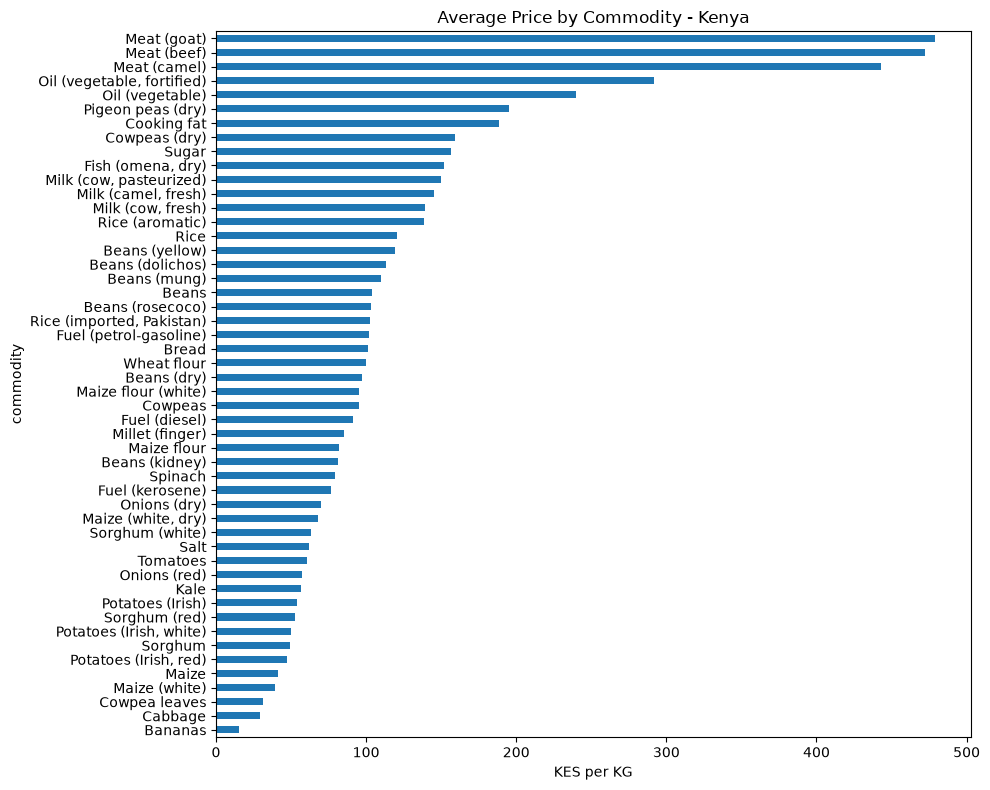

In [140]:
#average price per commodity

avg_price = df_clean.groupby("commodity")["price_per_kg"].mean().sort_values()

plt.figure(figsize=(10,8))
avg_price.plot(kind='barh')
plt.title("Average Price by Commodity - Kenya")
plt.xlabel("KES per KG")
plt.tight_layout()
plt.show()

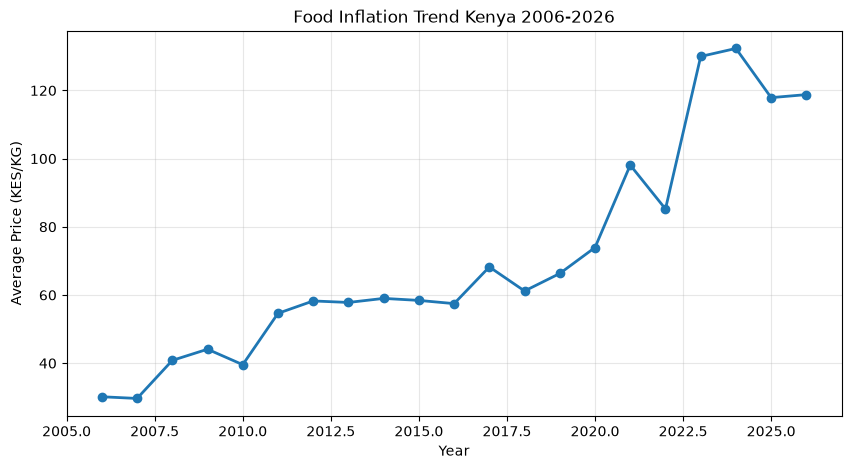

date
2006     30.151222
2007     29.655043
2008     40.815498
2009     44.091845
2010     39.557286
2011     54.613162
2012     58.253825
2013     57.809655
2014     59.001299
2015     58.411682
2016     57.466884
2017     68.232804
2018     61.169965
2019     66.310841
2020     73.929301
2021     98.102890
2022     85.226765
2023    129.968043
2024    132.315331
2025    117.885583
2026    118.774824
Name: price_per_kg, dtype: float64


In [141]:
#food inflation trend over the years

df_clean["date"] = pd.to_datetime(df_clean["date"])
yearly = df_clean.groupby(df_clean["date"].dt.year)["price_per_kg"].mean()

plt.figure(figsize=(10,5))
yearly.plot(marker='o', linewidth=2)
plt.title("Food Inflation Trend Kenya 2006-2026")
plt.ylabel("Average Price (KES/KG)")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.show()

print(yearly)

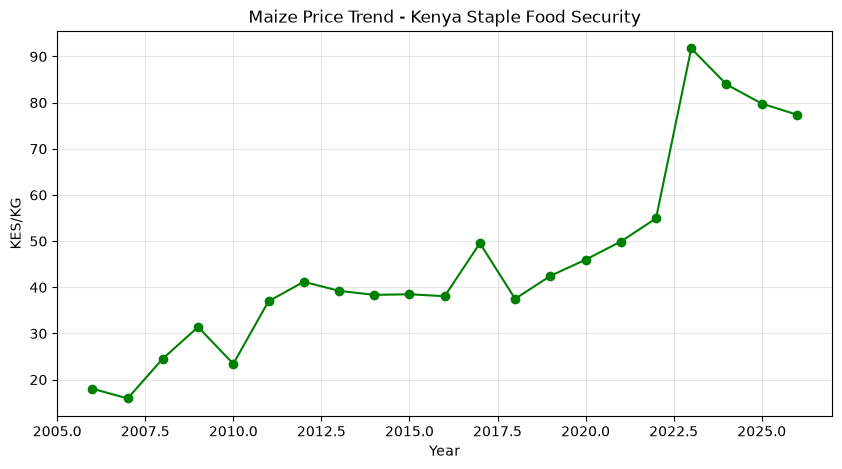

In [142]:
#maize price trend over the years

maize = df_clean[df_clean["commodity"].str.contains("Maize", case=False)]
maize_yearly = maize.groupby(maize["date"].dt.year)["price_per_kg"].mean()

plt.figure(figsize=(10,5))
maize_yearly.plot(marker='o', color='green')
plt.title("Maize Price Trend - Kenya Staple Food Security")
plt.ylabel("KES/KG")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.show()

In [143]:
print(df_clean.columns)

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice', 'date_month',
       'rainfall_mm', 'kg', 'price_per_kg'],
      dtype='str')


In [144]:
#check correlation between rainfall and price per kg

corr = df_clean["price_per_kg"].corr(df_clean["rainfall_mm"])
print(f"Correlation rainfall vs price: {corr:.3f}")

Correlation rainfall vs price: -0.046


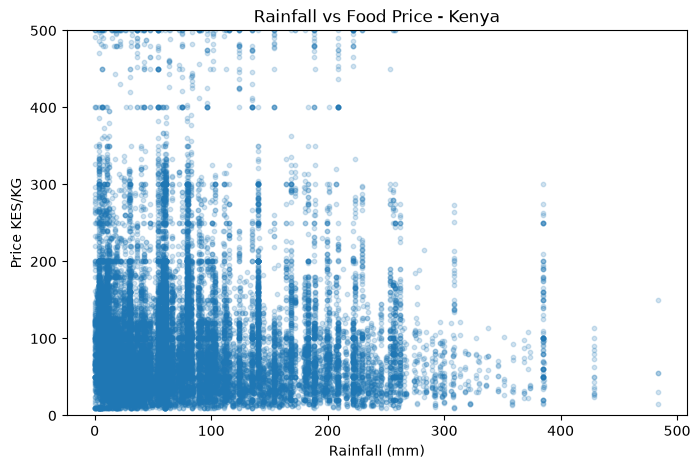

In [145]:
#scatter to visualize the relationship between rainfall and price per kg
#extreme high prices happen during dry periods

plt.figure(figsize=(8,5))
plt.scatter(df_clean["rainfall_mm"], df_clean["price_per_kg"], alpha=0.2, s=10)
plt.title("Rainfall vs Food Price - Kenya")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Price KES/KG")
plt.ylim(0, 500) #cut outlier for visibility
plt.show()

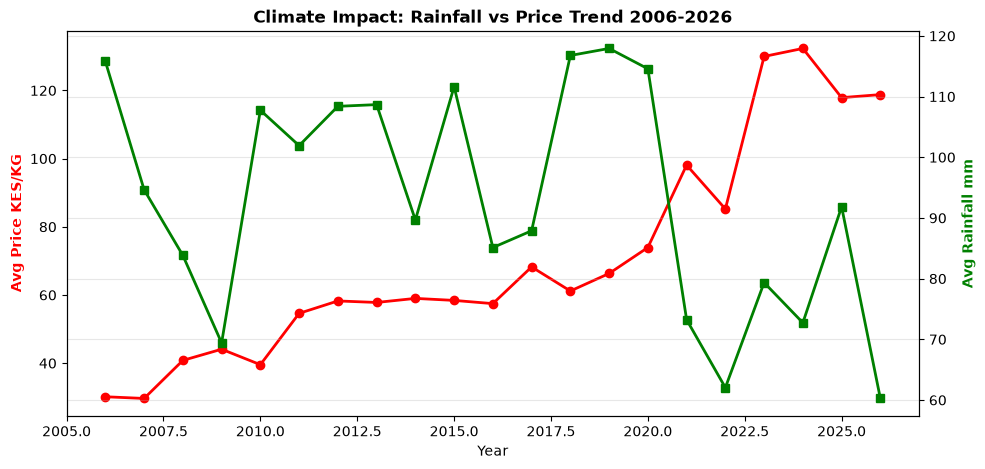

date
2006     30.151222
2007     29.655043
2008     40.815498
2009     44.091845
2010     39.557286
2011     54.613162
2012     58.253825
2013     57.809655
2014     59.001299
2015     58.411682
2016     57.466884
2017     68.232804
2018     61.169965
2019     66.310841
2020     73.929301
2021     98.102890
2022     85.226765
2023    129.968043
2024    132.315331
2025    117.885583
2026    118.774824
Name: price_per_kg, dtype: float64
date
2006    115.797229
2007     94.646369
2008     83.824212
2009     69.412402
2010    107.748055
2011    101.917152
2012    108.393403
2013    108.674900
2014     89.666243
2015    111.628224
2016     85.122222
2017     87.888203
2018    116.770699
2019    117.930071
2020    114.579093
2021     73.236164
2022     62.041791
2023     79.346559
2024     72.729177
2025     91.832704
2026     60.260000
Name: rainfall_mm, dtype: float64
Yearly corr: -0.515


In [146]:
#climate impact: rainfall vs price trend over the years

yearly_price = df_clean.groupby(df_clean["date"].dt.year)["price_per_kg"].mean()
yearly_rain = df_clean.groupby(df_clean["date"].dt.year)["rainfall_mm"].mean()

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(yearly_price.index, yearly_price.values, marker='o', color='red', linewidth=2)
ax1.set_ylabel("Avg Price KES/KG", color='red', fontweight='bold')
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(yearly_rain.index, yearly_rain.values, marker='s', color='green', linewidth=2)
ax2.set_ylabel("Avg Rainfall mm", color='green', fontweight='bold')

plt.title("Climate Impact: Rainfall vs Price Trend 2006-2026", fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print(yearly_price)
print(yearly_rain)
corr_yearly = yearly_price.corr(yearly_rain)
print(f"Yearly corr: {corr_yearly:.3f}")

In [147]:
#top 5 most expensive and cheapest commodities

print(df_clean.groupby('commodity')['price_per_kg'].mean().sort_values(ascending=False).head())
print(df_clean.groupby('commodity')['price_per_kg'].mean().sort_values().head())

commodity
Meat (goat)                   478.676893
Meat (beef)                   472.255769
Meat (camel)                  443.005172
Oil (vegetable, fortified)    291.731744
Oil (vegetable)               239.742700
Name: price_per_kg, dtype: float64
commodity
Bananas          15.654419
Cabbage          29.026209
Cowpea leaves    31.262500
Maize (white)    39.275379
Maize            41.427352
Name: price_per_kg, dtype: float64
